<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.6;
  color: var(--vscode-editor-foreground);
">

  <div style="
    border-left: 4px solid var(--vscode-focusBorder);
    padding: 14px 18px;
    margin-bottom: 18px;
    background: var(--vscode-editorWidget-background);
    border-radius: 8px;
  ">
    <h2 style="margin: 0 0 6px 0; font-size: 24px;">
      Notebook 4: Hierarchical Clustering and Gap Statistic
    </h2>
    <p style="margin: 0; opacity: 0.85;">
      Building tree-based customer segments and selecting a practical number of clusters.
    </p>
  </div>

  <h3 style="margin-top: 18px;">What we are doing</h3>

  <p>
    In Notebook 2, we created the main <strong>K-Means k = 5</strong> customer segmentation baseline.
  </p>

  <p>
    In Notebook 3, we added density methods such as DBSCAN, OPTICS, density scoring, grid views,
    and business-rule segments.
  </p>

  <p>
    Now we study a different clustering idea:
  </p>

  <div style="
    border-left: 4px solid #38bdf8;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Hierarchical clustering builds a customer tree.</strong><br>
    Similar customers are joined first. Larger groups are joined later.
  </div>

  <h3 style="margin-top: 22px;">Topics covered</h3>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Topic</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Why it matters</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Ward hierarchical clustering</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Create tree-based customer groups from scaled RFM behaviour.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Dendrogram</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Visualise how customer groups merge step by step.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Cut threshold</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Choose where to cut the tree into clusters.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Gap Statistic</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Test k = 1 to 8 with B = 10 reference datasets.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Final comparison</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Compare Hierarchical, K-Means and DBSCAN using clustering metrics.</td>
      </tr>
    </tbody>
  </table>

  <div style="
    border-left: 4px solid #22c55e;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Final goal:</strong><br>
    Decide whether hierarchical clustering gives a useful segmentation view, and compare it against the existing K-Means and DBSCAN results.
  </div>

</div>


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">1. Load the prepared data</h3>

  <p>
    We continue from the earlier notebooks.
  </p>

  <p>
    We do <strong>not</strong> clean the raw Online Retail data again here.
    Notebook 1 already created the RFM customer table and scaled RFM features.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Previous output</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Used for</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Original RFM table</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Business interpretation of clusters.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Scaled RFM features</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Hierarchical clustering and Gap Statistic.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>K-Means labels</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Comparison with the partitioning baseline.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>DBSCAN labels</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Comparison with the density-based result.</td>
      </tr>
    </tbody>
  </table>

  <div style="
    border-left: 4px solid #38bdf8;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Goal of this step:</strong><br>
    Load the prepared customer data and previous clustering outputs so we can focus only on hierarchical clustering.
  </div>

</div>


In [1]:
# ------------------------------------------------------------
# 1.1 Import libraries and set project folders
# ------------------------------------------------------------
# Goal:
# Load the tools needed for hierarchical clustering, Gap Statistic, charts, and HTML explanations.

from pathlib import Path                  # create clean relative folder paths
import warnings                           # hide non-critical warning messages

import numpy as np                        # numerical calculations
import pandas as pd                       # table loading, joining, grouping and saving
import matplotlib.pyplot as plt           # charts and visual explanations

from IPython.display import display, HTML # show tables and styled HTML Markdown inside the notebook

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster   # Ward tree, dendrogram and tree cuts
from sklearn.cluster import AgglomerativeClustering                 # hierarchical clustering model
from sklearn.decomposition import PCA                               # 2D customer map for visualisation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score  # cluster scores

# Keep notebook output clean.
warnings.filterwarnings("ignore")

# Make matplotlib plots display inside the notebook when the environment supports it.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# Make plots sharper and easier to read.
plt.rcParams["figure.dpi"] = 120

# Use only relative folders. No personal machine paths.
OUTPUT_DIR = Path("outputs")
REPORT_DIR = Path("reports")

# Create folders if they do not already exist.
OUTPUT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

print("Libraries loaded successfully.")
print(f"Output folder: {OUTPUT_DIR}")
print(f"Report folder: {REPORT_DIR}")

Libraries loaded successfully.
Output folder: outputs
Report folder: reports


In [2]:
# ------------------------------------------------------------
# 1.2 Load prepared outputs from earlier notebooks
# ------------------------------------------------------------
# Goal:
# Continue from Notebook 1, Notebook 2 and Notebook 3 outputs.

required_files = [
    "rfm_customer_table.csv",               # original customer-level RFM table
    "rfm_scaled.csv",                       # scaled RFM values used for clustering
    "customer_partitioning_clusters.csv",   # K-Means customer labels from Notebook 2
    "partitioning_method_comparison.csv",   # K-Means / partitioning comparison from Notebook 2
    "dbscan_practical_labels.csv"           # practical DBSCAN labels from Notebook 3
]

# Check whether all required files are available before the notebook continues.
missing_files = [
    file_name
    for file_name in required_files
    if not (OUTPUT_DIR / file_name).exists()
]

# Stop with a clear message if any required file is missing.
if missing_files:
    raise FileNotFoundError(
        "Missing required files in outputs/:\n" + "\n".join(missing_files)
    )

# Load original RFM values for business interpretation.
rfm = pd.read_csv(OUTPUT_DIR / "rfm_customer_table.csv")

# Load scaled RFM values for clustering calculations.
rfm_scaled = pd.read_csv(OUTPUT_DIR / "rfm_scaled.csv")

# Load previous clustering outputs for comparison.
customer_partitioning = pd.read_csv(OUTPUT_DIR / "customer_partitioning_clusters.csv")
partitioning_comparison = pd.read_csv(OUTPUT_DIR / "partitioning_method_comparison.csv")
dbscan_result = pd.read_csv(OUTPUT_DIR / "dbscan_practical_labels.csv")

# Select the scaled RFM features used by Ward clustering.
scaled_columns = ["Recency_Scaled", "Frequency_Scaled", "Monetary_Scaled"]
X_scaled = rfm_scaled[scaled_columns].copy()

print("Data loaded successfully.")
print(f"Customers: {len(rfm):,}")
print(f"Scaled feature shape: {X_scaled.shape}")

display(rfm.head())
display(partitioning_comparison)

Data loaded successfully.
Customers: 4,312
Scaled feature shape: (4312, 3)


,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,Country,DominantProduct
0,12346,2010-06-28 13:53:00,165,11,372.86,70,26,United Kingdom,DOORMAT 3 SMILEY CATS
1,12347,2010-12-07 14:57:00,3,2,1323.32,828,70,Iceland,3D DOG PICTURE PLAYING CARDS
2,12348,2010-09-27 14:59:00,74,1,222.16,373,20,Finland,36 DOILIES VINTAGE CHRISTMAS
3,12349,2010-10-28 08:23:00,43,3,2671.14,993,90,Italy,LOVE HEART SOCK HANGER
4,12351,2010-11-29 15:23:00,11,1,300.93,261,21,Unspecified,BLUE SCANDINAVIAN PAISLEY WRAP


,Method,k,Clusters,Inertia,Runtime_Seconds,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means,5,5,2740.1154,NaN,0.6140,0.6304,4006.5535
1,MiniBatchKMeans,5,5,4960.4320,0.4714,0.4978,0.8053,2038.1327
2,K-Modes,5,5,NaN,NaN,-0.0544,5.4446,378.6454
3,Medoid-style fallback,5,5,NaN,NaN,0.6146,0.6278,4004.7829
4,K-Prototypes,5,5,NaN,NaN,0.3655,1.0870,1024.9517


In [3]:
# ------------------------------------------------------------
# 1.3 Explain loaded data using actual values
# ------------------------------------------------------------

customer_count = len(rfm)
feature_count = X_scaled.shape[1]

html = f"""
<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">What the loaded data means</h3>

  <p>
    The data is loaded successfully.
  </p>

  <p>
    We have <strong>{customer_count:,} customers</strong> and <strong>{feature_count} scaled RFM features</strong> for hierarchical clustering.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Data</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Purpose</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Original RFM</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Used to explain clusters in business language.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Scaled RFM</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Used for Ward hierarchical clustering and Gap Statistic.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>K-Means and DBSCAN outputs</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Used to compare hierarchical clustering with earlier methods.</td>
      </tr>
    </tbody>
  </table>

  <div style="
    border-left: 4px solid #22c55e;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Simple takeaway:</strong><br>
    This notebook starts from prepared customer-level data and focuses only on hierarchical clustering and final method comparison.
  </div>

</div>
"""

display(HTML(html))


Data,Purpose
Original RFM,Used to explain clusters in business language.
Scaled RFM,Used for Ward hierarchical clustering and Gap Statistic.
K-Means and DBSCAN outputs,Used to compare hierarchical clustering with earlier methods.


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">2. Helper functions</h3>

  <p>
    Before running hierarchical clustering, we create a few small helper functions.
  </p>

  <p>
    These functions keep the notebook clean and avoid repeating the same logic.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Helper</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Why we need it</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Clustering scores</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Compare how clear or messy the clusters are.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Cluster profile</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Turn cluster labels into business-friendly RFM summaries.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Ward clustering wrapper</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Run hierarchical clustering safely across sklearn versions.</td>
      </tr>
    </tbody>
  </table>

</div>


In [4]:
# ------------------------------------------------------------
# 2.1 Calculate clustering scores
# ------------------------------------------------------------
# Goal:
# Reuse one safe function to score K-Means, DBSCAN and Hierarchical clustering.

def calculate_clustering_scores(X, cluster_labels, ignore_noise=False, sample_size=2000):

    # Convert labels into a NumPy array so metric functions can read them safely.
    labels = np.asarray(cluster_labels)

    # DBSCAN uses label -1 for noise. We can ignore it when scoring real DBSCAN clusters.
    if ignore_noise:
        keep_mask = labels != -1
        X_for_score = X.loc[keep_mask] if hasattr(X, "loc") else X[keep_mask]
        labels_for_score = labels[keep_mask]
    else:
        X_for_score = X
        labels_for_score = labels

    # Count how many different labels are available for scoring.
    unique_labels = np.unique(labels_for_score)

    # Metrics are not valid if there is only one cluster or if every row is its own cluster.
    if len(unique_labels) < 2 or len(unique_labels) >= len(labels_for_score):
        return {
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan
        }

    # Silhouette can be slow, so use a sample when the dataset is large.
    if len(labels_for_score) > sample_size:
        silhouette_value = silhouette_score(
            X_for_score,
            labels_for_score,
            sample_size=sample_size,
            random_state=42
        )
    else:
        silhouette_value = silhouette_score(X_for_score, labels_for_score)

    # Return the three standard clustering quality scores.
    return {
        "Silhouette": silhouette_value,
        "Davies_Bouldin": davies_bouldin_score(X_for_score, labels_for_score),
        "Calinski_Harabasz": calinski_harabasz_score(X_for_score, labels_for_score)
    }

In [5]:
# ------------------------------------------------------------
# 2.2 Create business profile for cluster labels
# ------------------------------------------------------------
# Goal:
# Convert cluster numbers into business-readable customer profiles.

def create_cluster_profile(cluster_labels, label_name):

    # Keep original RFM values because they are easier to explain than scaled values.
    profile_data = rfm[[
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "Country"
    ]].copy()

    # Attach the cluster label created by the selected method.
    profile_data[label_name] = cluster_labels

    # Summarise customer behaviour inside each cluster.
    profile = (
        profile_data
        .groupby(label_name)
        .agg(
            Customers=("CustomerID", "count"),
            Avg_Recency=("Recency", "mean"),
            Avg_Frequency=("Frequency", "mean"),
            Avg_Monetary=("Monetary", "mean"),
            Total_Monetary=("Monetary", "sum")
        )
        .reset_index()
    )

    # Add customer share so we can see how large each cluster is.
    profile["Customer_Share_%"] = profile["Customers"] / len(profile_data) * 100

    # Add revenue share so we can see how financially important each cluster is.
    profile["Revenue_Share_%"] = profile["Total_Monetary"] / profile_data["Monetary"].sum() * 100

    # Round the final table for clean display.
    return profile.round(2)

In [6]:
# ------------------------------------------------------------
# 2.3 Run Ward hierarchical clustering safely
# ------------------------------------------------------------
# Goal:
# Run Ward clustering in a way that works across different sklearn versions.

def run_ward_clustering(X, n_clusters):

    # First try the newer sklearn argument name: metric.
    try:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage="ward",
            metric="euclidean"
        )

    # Older sklearn versions use affinity instead of metric.
    except TypeError:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage="ward",
            affinity="euclidean"
        )

    # Fit the model and return one cluster label for each customer.
    return model.fit_predict(X)

In [7]:
# ------------------------------------------------------------
# 2.4 Create a simple PCA customer map
# ------------------------------------------------------------
# Goal:
# Compress the three scaled RFM features into two visual columns: PC1 and PC2.

# Create a PCA model with two components for visualisation.
pca = PCA(n_components=2, random_state=42)

# Fit PCA on scaled RFM data and transform customers into 2D positions.
pca_values = pca.fit_transform(X_scaled)

# Store the PCA position together with CustomerID.
pca_view = pd.DataFrame({
    "CustomerID": rfm_scaled["CustomerID"],
    "PC1": pca_values[:, 0],
    "PC2": pca_values[:, 1]
})

# Calculate how much of the scaled RFM structure is visible in the 2D map.
pca_variance = pca.explained_variance_ratio_.sum()

print(f"PC1 + PC2 explain {pca_variance:.2%} of the scaled RFM structure.")

display(pca_view.head())

PC1 + PC2 explain 88.96% of the scaled RFM structure.


,CustomerID,PC1,PC2
0,12346,0.171102,0.752213
1,12347,0.045012,-0.915082
2,12348,-0.362528,-0.289656
3,12349,0.089845,-0.462995
4,12351,-0.140669,-0.892921


In [8]:
# ------------------------------------------------------------
# 2.5 Draw customer cluster map
# ------------------------------------------------------------
# Goal:
# Reuse one plotting function for PCA-based cluster maps.

def plot_cluster_map(pca_table, cluster_labels, chart_title):

    # Copy PCA coordinates so the original pca_view table is not changed.
    chart_data = pca_table.copy()

    # Add cluster labels to the PCA map.
    chart_data["Cluster"] = cluster_labels

    # Start a clean figure.
    plt.figure(figsize=(10, 6))

    # Draw one dot per customer.
    scatter = plt.scatter(
        chart_data["PC1"],
        chart_data["PC2"],
        c=chart_data["Cluster"],
        s=18,
        alpha=0.55
    )

    # Add chart labels and visual polish.
    plt.title(chart_title, fontsize=14, weight="bold")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

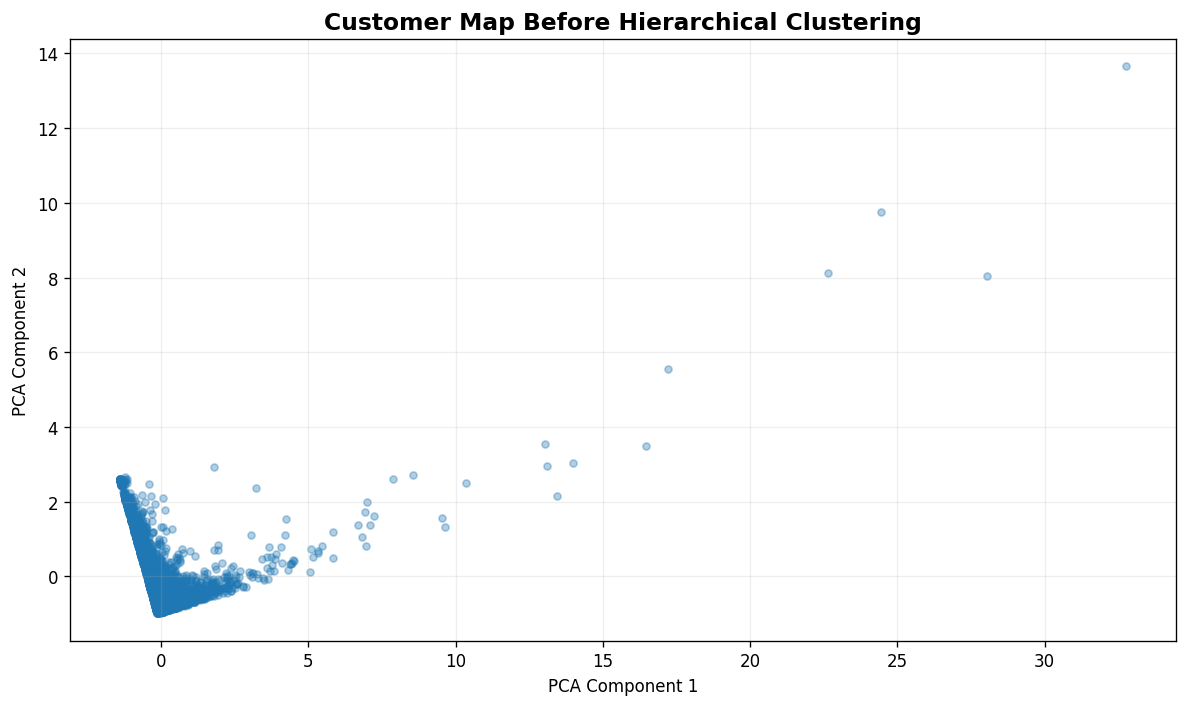

In [9]:
# ------------------------------------------------------------
# 2.6 Draw PCA customer map before clustering
# ------------------------------------------------------------
# Goal:
# Show the customer space before adding hierarchical cluster labels.

# Start a clean figure.
plt.figure(figsize=(10, 6))

# Draw each customer as one dot on the PCA map.
plt.scatter(
    pca_view["PC1"],
    pca_view["PC2"],
    s=18,
    alpha=0.35
)

# Add chart labels and make the chart readable.
plt.title("Customer Map Before Hierarchical Clustering", fontsize=14, weight="bold")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [10]:
# ------------------------------------------------------------
# 2.7 Explain PCA map using actual values
# ------------------------------------------------------------
# Goal:
# Add a short conclusion after the PCA map.

html = f"""
<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">What the PCA map means</h3>

  <p>
    The 2D PCA map explains <strong>{pca_variance:.2%}</strong> of the scaled RFM structure.
  </p>

  <p>
    This is strong enough for visual checking because most customer-behaviour information is still visible in the map.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">What you see</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Simple meaning</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Dots close together</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Customers have similar RFM behaviour.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Dots far away</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Customers behave differently or may be unusual.</td>
      </tr>
    </tbody>
  </table>

  <div style="
    border-left: 4px solid #38bdf8;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Important:</strong><br>
    PCA is used here only for visual explanation.
    Ward clustering and Gap Statistic still use the scaled RFM features.
  </div>

</div>
"""

display(HTML(html))

What you see,Simple meaning
Dots close together,Customers have similar RFM behaviour.
Dots far away,Customers behave differently or may be unusual.


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">3. Hierarchical clustering concept</h3>

  <p>
    Hierarchical clustering builds clusters like a tree.
  </p>

  <p>
    It starts with every customer alone.
    Then it joins the most similar customers or groups step by step.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Step</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Simple meaning</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Start</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Every customer is alone.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Merge</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">The closest customers or groups are joined.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Tree</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">We get a dendrogram that shows how groups combine.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Cut</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">We cut the tree to choose final clusters.</td>
      </tr>
    </tbody>
  </table>

  <div style="
    border-left: 4px solid #38bdf8;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Simple idea:</strong><br>
    K-Means directly creates groups. Hierarchical clustering first builds a tree, then we decide where to cut it.
  </div>

</div>


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">4. Ward linkage</h3>

  <p>
    In this notebook, we use <strong>Ward linkage</strong>.
  </p>

  <p>
    Ward tries to merge customer groups in a way that keeps the groups compact.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Concept</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Simple meaning</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Compact group</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Customers inside the group are similar to each other.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Ward merge</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Merge the groups that increase internal spread the least.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Euclidean distance</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Distance measure used on scaled RFM features.</td>
      </tr>
    </tbody>
  </table>

  <div style="
    border-left: 4px solid #22c55e;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Why Ward is useful here:</strong><br>
    We want customer groups that are not too messy. Ward linkage is a good practical choice for compact RFM-based customer segments.
  </div>

</div>


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">5. Dendrogram</h3>

  <p>
    A dendrogram is the tree picture of hierarchical clustering.
  </p>

  <p>
    It shows how small customer groups merge into larger groups.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">What you see</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Meaning</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Short merge height</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Groups are similar.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Tall merge height</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Groups are quite different.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Horizontal cut line</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Where we cut the tree into clusters.</td>
      </tr>
    </tbody>
  </table>

  <div style="
    border-left: 4px solid #f59e0b;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Important:</strong><br>
    A full dendrogram with thousands of customers is hard to read. So we draw the dendrogram on a fixed sample for visual explanation.
  </div>

</div>


In [11]:
# ------------------------------------------------------------
# 5.1 Create a dendrogram sample and linkage matrix
# ------------------------------------------------------------
# Goal:
# Build a readable Ward dendrogram from a practical customer sample.

# Use a sample so the dendrogram is readable and not overloaded.
DENDROGRAM_SAMPLE_SIZE = 800

# Take a fixed sample if the dataset is larger than the dendrogram limit.
if len(X_scaled) > DENDROGRAM_SAMPLE_SIZE:
    X_dendrogram = X_scaled.sample(
        n=DENDROGRAM_SAMPLE_SIZE,
        random_state=42
    ).copy()
else:
    X_dendrogram = X_scaled.copy()

# Ward linkage creates the hierarchical merge tree from the sample.
linkage_matrix = linkage(
    X_dendrogram.values,
    method="ward",
    metric="euclidean"
)

print(f"Dendrogram sample size: {len(X_dendrogram):,} customers")
print(f"Linkage matrix shape: {linkage_matrix.shape}")

Dendrogram sample size: 800 customers
Linkage matrix shape: (799, 4)


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">What the dendrogram sample output means</h3>

  <p>
    The dendrogram was created using a sample of <strong>800 customers</strong>.
  </p>

  <p>
    Hierarchical clustering starts with each customer as its own small group.
    Then it keeps merging the closest groups until everything becomes one large group.
  </p>

  <div style="
    border-left: 4px solid #38bdf8;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Simple rule:</strong><br>
    For <strong>n</strong> customers, hierarchical clustering creates <strong>n - 1</strong> merge steps.
  </div>

  <p>
    Since we used <strong>800 customers</strong>, the linkage matrix has:
  </p>

  <div style="
    border-left: 4px solid #22c55e;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>800 - 1 = 799 merge rows</strong>
  </div>

  <p>
    That is why the linkage matrix shape is <strong>(799, 4)</strong>.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Part</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Meaning</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>799 rows</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">One row for each merge step.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>4 columns</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Information about which groups merged, merge distance, and group size.</td>
      </tr>
    </tbody>
  </table>

  <p>
    This confirms that the dendrogram was built correctly.
  </p>

</div>

In [12]:
# ------------------------------------------------------------
# 5.2 Inspect the largest merge distances
# ------------------------------------------------------------
# Goal:
# Look for large jumps in merge distance near the top of the dendrogram.

# Column 2 of linkage_matrix contains the Ward merge distance.
merge_distances = linkage_matrix[:, 2]

# Create a table of all merge distances.
merge_distance_table = pd.DataFrame({
    "Merge_Number": np.arange(1, len(merge_distances) + 1),
    "Merge_Distance": merge_distances
})

# Keep only the final merges because they show the largest high-level group joins.
last_merge_distances = merge_distance_table.tail(12).copy()

# Calculate the jump from one merge distance to the next.
last_merge_distances["Distance_Jump"] = last_merge_distances["Merge_Distance"].diff()

last_merge_distances.round(4)

,Merge_Number,Merge_Distance,Distance_Jump
787,788,4.7253,NaN
788,789,5.8338,1.1085
789,790,6.1358,0.3020
790,791,6.4388,0.3029
791,792,8.8031,2.3643
792,793,9.6013,0.7982
793,794,11.1367,1.5354
794,795,11.1964,0.0597
795,796,15.7900,4.5936
796,797,19.5687,3.7787


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">What the merge-distance table means</h3>

  <p>
    This table helps us choose where to cut the dendrogram.
  </p>

  <p>
    In hierarchical clustering, each row represents one merge.
    A merge means two customer groups were joined together.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Column</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Meaning</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Merge Number</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">The step number in the hierarchical merging process.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Merge Distance</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">How different the groups were when they were merged.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Distance Jump</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">How much the merge distance increased from the previous merge.</td>
      </tr>
    </tbody>
  </table>

  <p>
    The most important row is the large jump from merge <strong>797</strong> to merge <strong>798</strong>.
  </p>

  <div style="
    border-left: 4px solid #38bdf8;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    Merge distance jumps from <strong>19.5687</strong> to <strong>35.6809</strong>.<br>
    The jump is <strong>16.1122</strong>, which is the largest jump in this table.
  </div>

  <p>
    This means that after merge 797, the model still has three meaningful customer groups.
    The next merge would force two large and different groups together.
  </p>

  <p>
    Because the sample has 800 customers, the cluster count after merge 797 is:
  </p>

  <div style="
    border-left: 4px solid #f59e0b;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>800 - 797 = 3 clusters</strong>
  </div>

  <p>
    Therefore, we cut the dendrogram between <strong>19.5687</strong> and <strong>35.6809</strong>.
    The selected cut threshold <strong>27.62</strong> sits between those values.
  </p>

  <div style="
    border-left: 4px solid #22c55e;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Conclusion:</strong><br>
    The merge-distance jump supports using <strong>3 hierarchical clusters</strong>.
    This is a practical choice because it keeps the major customer groups separate before the model starts merging very different groups together.
  </div>

</div>

In [13]:
# ------------------------------------------------------------
# 5.3 Choose a dendrogram cut threshold
# ------------------------------------------------------------
# Goal:
# Choose a visual cut point based on a large jump in merge distance.

# Focus on the final 20 merge distances.
recent_distances = merge_distances[-20:]

# Calculate jumps between neighbouring final merge distances.
recent_jumps = np.diff(recent_distances)

# Find the largest jump position.
largest_jump_position = int(np.argmax(recent_jumps))

# Read the lower and upper distance around that jump.
threshold_low = recent_distances[largest_jump_position]
threshold_high = recent_distances[largest_jump_position + 1]

# Use the midpoint as a practical dendrogram cut threshold.
dendrogram_threshold = (threshold_low + threshold_high) / 2

# Cut the sample dendrogram at this threshold.
sample_cut_labels = fcluster(
    linkage_matrix,
    t=dendrogram_threshold,
    criterion="distance"
)

# Count how many sample clusters this cut creates.
dendrogram_suggested_k = len(np.unique(sample_cut_labels))

print(f"Suggested dendrogram cut threshold: {dendrogram_threshold:.4f}")
print(f"Suggested sample clusters from cut: {dendrogram_suggested_k}")

Suggested dendrogram cut threshold: 27.6248
Suggested sample clusters from cut: 3


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">How we selected the final hierarchical k</h3>

  <p>
    The different selection checks gave different answers.
    This is normal in clustering because there is no single perfect answer.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Result</th>
        <th style="text-align: right; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Value</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Meaning</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Gap rule k</strong></td>
        <td style="text-align: right; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">1</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">The strict Gap rule selected one cluster, but one cluster is not useful for customer segmentation.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Highest raw Gap k</strong></td>
        <td style="text-align: right; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">8</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">The highest raw Gap value appears at 8 clusters, but this may create too many small groups for a clean business story.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Dendrogram suggested k</strong></td>
        <td style="text-align: right; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">3</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">The dendrogram shows a strong natural split into three main customer groups.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Selected practical k</strong></td>
        <td style="text-align: right; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">3</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">This is the final practical choice for hierarchical clustering.</td>
      </tr>
    </tbody>
  </table>

  <div style="
    border-left: 4px solid #f59e0b;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Important:</strong><br>
    We do not blindly use <code>k = 1</code> or <code>k = 8</code>.
    <code>k = 1</code> gives no segmentation, and <code>k = 8</code> may be too fragmented for business use.
  </div>

  <div style="
    border-left: 4px solid #22c55e;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Final decision:</strong><br>
    We use <strong>k = 3</strong> for hierarchical clustering because it is supported by the dendrogram,
    keeps the main customer groups separate, and gives a cleaner business explanation.
  </div>

</div>

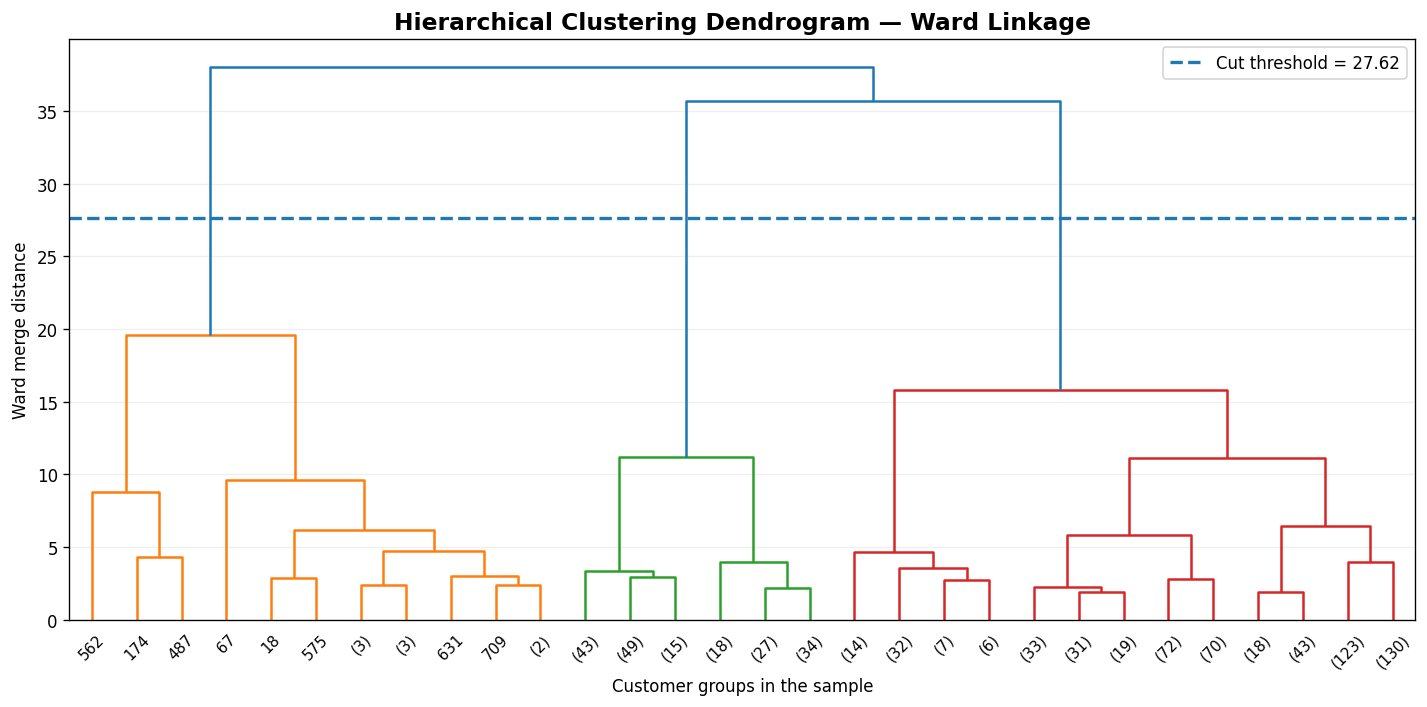

In [14]:
# ------------------------------------------------------------
# 5.4 Draw dendrogram with selected cut threshold
# ------------------------------------------------------------
# The dendrogram is truncated so the chart stays readable.

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=45,
    leaf_font_size=9,
    color_threshold=dendrogram_threshold
)

plt.axhline(
    dendrogram_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Cut threshold = {dendrogram_threshold:.2f}"
)

plt.title("Hierarchical Clustering Dendrogram — Ward Linkage", fontsize=14, weight="bold")
plt.xlabel("Customer groups in the sample")
plt.ylabel("Ward merge distance")
plt.grid(axis="y", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">What the dendrogram means</h3>

  <p>
    This dendrogram shows how Ward hierarchical clustering merged customer groups step by step.
  </p>

  <p>
    At the bottom, we see smaller customer groups.
    As we move upward, similar groups are merged into larger groups.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Part of chart</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Meaning</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Bottom labels</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Customer groups in the sampled dendrogram.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Vertical height</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">How different two groups are when they merge.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Low merge</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Groups are similar.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>High merge</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Groups are very different.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Dashed line</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">The selected cut threshold.</td>
      </tr>
    </tbody>
  </table>

  <p>
    The dashed cut line is placed at <strong>27.62</strong>.
    When we cut the dendrogram at this height, the tree separates into <strong>3 main customer groups</strong>.
  </p>

  <div style="
    border-left: 4px solid #38bdf8;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Simple reading:</strong><br>
    The orange, green, and red branches below the dashed line represent the three practical hierarchical clusters.
  </div>

  <p>
    Above the dashed line, the model would start merging these large groups together.
    That would reduce the segmentation into fewer groups and make the customer structure too broad.
  </p>

  <div style="
    border-left: 4px solid #22c55e;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Conclusion:</strong><br>
    The dendrogram supports using <strong>3 hierarchical clusters</strong>.
    This is a practical choice because it keeps the main customer groups separate without making the result too fragmented.
  </div>

  <p>
    Some bottom labels appear inside brackets, such as <code>(43)</code> or <code>(130)</code>.
    This means the dendrogram is compressed for readability, and that label represents a collapsed group of customers rather than one single customer.
  </p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">6. Gap Statistic</h3>

  <p>
    The Gap Statistic helps us choose a practical number of clusters.
  </p>

  <p>
    It compares our real customer data against random reference data.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Data type</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Meaning</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Real data</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Actual customer RFM behaviour.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Reference data</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Random data with no real customer structure.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Gap value</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">How much better the real clustering is compared with random data.</td>
      </tr>
    </tbody>
  </table>

  <div style="
    border-left: 4px solid #38bdf8;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>MVD requirement:</strong><br>
    Test <code>k = 1 to 8</code> using <code>B = 10</code> reference datasets and plot Gap Statistic with error bars.
  </div>

</div>


In [16]:
# ------------------------------------------------------------
# 6.1 Helper function: within-cluster dispersion
# ------------------------------------------------------------
# Goal:
# Measure how tightly customers sit inside their assigned clusters.

def within_cluster_dispersion(X_values, labels):

    # Convert inputs to NumPy arrays for distance calculation.
    X_array = np.asarray(X_values)
    labels = np.asarray(labels)

    # Start total dispersion at zero.
    total_dispersion = 0.0

    # Calculate dispersion inside each cluster.
    for cluster_id in np.unique(labels):

        # Select customers belonging to the current cluster.
        cluster_points = X_array[labels == cluster_id]

        # Calculate the centre of the current cluster.
        cluster_center = cluster_points.mean(axis=0)

        # Calculate squared distance from each customer to the cluster centre.
        squared_distances = ((cluster_points - cluster_center) ** 2).sum(axis=1)

        # Add this cluster's dispersion to the total.
        total_dispersion += squared_distances.sum()

    # Return total within-cluster dispersion.
    return total_dispersion

In [17]:
# ------------------------------------------------------------
# 6.2 Helper function: run hierarchical labels for any k
# ------------------------------------------------------------
# Goal:
# Return hierarchical cluster labels for any tested k value.

def hierarchical_labels_for_k(X, k):

    # k = 1 means all customers are placed into one single group.
    if k == 1:
        return np.zeros(len(X), dtype=int)

    # For k >= 2, run Ward hierarchical clustering.
    return run_ward_clustering(X, n_clusters=k)

In [18]:
# ------------------------------------------------------------
# 6.3 Run Gap Statistic for k = 1 to 8 and B = 10
# ------------------------------------------------------------
# Goal:
# Compare real customer structure against random reference data.

# MVD requirement: test k from 1 to 8.
k_values = list(range(1, 9))

# MVD requirement: use 10 bootstrap reference datasets.
B = 10

# Use a practical sample so the calculation stays notebook-friendly.
GAP_SAMPLE_SIZE = 2500

# Sample the scaled RFM table if it is larger than the Gap sample limit.
if len(X_scaled) > GAP_SAMPLE_SIZE:
    X_gap = X_scaled.sample(n=GAP_SAMPLE_SIZE, random_state=42).reset_index(drop=True)
else:
    X_gap = X_scaled.reset_index(drop=True).copy()

# Convert sample data to NumPy for faster calculations.
X_gap_values = X_gap.values

# Use a fixed random generator for reproducible reference datasets.
rng = np.random.default_rng(42)

# Get the minimum value for each feature.
feature_min = X_gap_values.min(axis=0)

# Get the maximum value for each feature.
feature_max = X_gap_values.max(axis=0)

# Store one result row per k.
gap_records = []

for k in k_values:

    # Run hierarchical clustering on real customer data for this k.
    real_labels = hierarchical_labels_for_k(X_gap, k)

    # Calculate real within-cluster dispersion.
    real_dispersion = within_cluster_dispersion(X_gap_values, real_labels)

    # Convert dispersion to log scale for Gap Statistic.
    log_real_dispersion = np.log(max(real_dispersion, 1e-12))

    # Store reference dispersions for this k.
    reference_log_dispersions = []

    for bootstrap_id in range(B):

        # Create random data inside the same feature range as the real customers.
        reference_values = rng.uniform(
            low=feature_min,
            high=feature_max,
            size=X_gap_values.shape
        )

        # Run hierarchical clustering on the random reference data.
        reference_labels = hierarchical_labels_for_k(reference_values, k)

        # Calculate reference within-cluster dispersion.
        reference_dispersion = within_cluster_dispersion(reference_values, reference_labels)

        # Store the log reference dispersion.
        reference_log_dispersions.append(np.log(max(reference_dispersion, 1e-12)))

    # Average reference log dispersion across the 10 bootstrap runs.
    mean_reference_log = np.mean(reference_log_dispersions)

    # Standard deviation of reference log dispersions.
    std_reference_log = np.std(reference_log_dispersions, ddof=1)

    # Gap value: random reference dispersion minus real data dispersion.
    gap_value = mean_reference_log - log_real_dispersion

    # Gap error term used by the standard Gap rule.
    gap_error = std_reference_log * np.sqrt(1 + 1 / B)

    # Save results for this k.
    gap_records.append({
        "k": k,
        "Log_Real_Dispersion": log_real_dispersion,
        "Mean_Log_Reference_Dispersion": mean_reference_log,
        "Gap": gap_value,
        "Gap_Error": gap_error
    })

    print(f"Completed Gap Statistic for k={k}")

# Create final Gap Statistic table.
gap_results = pd.DataFrame(gap_records).round(4)

# Save Gap Statistic results for documentation.
gap_results.to_csv(
    OUTPUT_DIR / "hierarchical_gap_statistic_results.csv",
    index=False
)

gap_results

Completed Gap Statistic for k=1
Completed Gap Statistic for k=2
Completed Gap Statistic for k=3
Completed Gap Statistic for k=4
Completed Gap Statistic for k=5
Completed Gap Statistic for k=6
Completed Gap Statistic for k=7
Completed Gap Statistic for k=8


,k,Log_Real_Dispersion,Mean_Log_Reference_Dispersion,Gap,Gap_Error
0,1,8.9530,12.5916,3.6386,0.0181
1,2,8.5934,12.1276,3.5342,0.0575
2,3,8.1531,11.7827,3.6295,0.0334
3,4,7.6896,11.3970,3.7074,0.0516
4,5,7.4741,11.2103,3.7362,0.0336
5,6,7.2672,11.0385,3.7713,0.0403
6,7,7.0069,10.9076,3.9007,0.0385
7,8,6.8357,10.7592,3.9234,0.0349


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">What the Gap Statistic table means</h3>

  <p>
    The Gap Statistic checks how many clusters may be useful.
  </p>

  <p>
    It compares the real customer data against random reference data.
    If the real clusters are much better than random clusters, the Gap value becomes larger.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Column</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Meaning</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>k</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Number of clusters tested.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Log Real Dispersion</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Cluster spread in the real customer data.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Mean Log Reference Dispersion</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Average cluster spread in random reference data.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Gap</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">How much better the real clustering is compared with random data.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Gap Error</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Uncertainty from the bootstrap reference samples.</td>
      </tr>
    </tbody>
  </table>

  <p>
    In this run, the Gap value generally increases as k increases.
    The highest tested Gap appears at <strong>k = 8</strong>.
  </p>

  <div style="
    border-left: 4px solid #f59e0b;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Important:</strong><br>
    A higher Gap does not automatically mean the best business segmentation.
    More clusters can improve mathematical separation, but they can also make the customer story harder to explain.
  </div>

  <div style="
    border-left: 4px solid #22c55e;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Final reading:</strong><br>
    Gap Statistic supports testing multiple k values, but the final practical choice should also consider the dendrogram, cluster profile, and business readability.
  </div>

</div>

In [19]:
# ------------------------------------------------------------
# 6.4 Select practical hierarchical k
# ------------------------------------------------------------
# Goal:
# Use Gap Statistic and dendrogram evidence without accepting an unusable one-cluster result.

# Start with no automatic Gap-rule selection.
gap_rule_k = None

# Standard Gap rule:
# choose the first k where Gap(k) >= Gap(k+1) - Gap_Error(k+1).
for row_index in range(len(gap_results) - 1):

    # Current Gap value.
    current_gap = gap_results.loc[row_index, "Gap"]

    # Next Gap value.
    next_gap = gap_results.loc[row_index + 1, "Gap"]

    # Next Gap error value.
    next_error = gap_results.loc[row_index + 1, "Gap_Error"]

    # Apply the standard Gap stopping rule.
    if current_gap >= next_gap - next_error:
        gap_rule_k = int(gap_results.loc[row_index, "k"])
        break

# If the rule never stops, keep the highest raw Gap k.
if gap_rule_k is None:
    gap_rule_k = int(gap_results.sort_values("Gap", ascending=False).iloc[0]["k"])

# Identify the k with the highest raw Gap value.
best_gap_k = int(gap_results.sort_values("Gap", ascending=False).iloc[0]["k"])

# Use dendrogram result as the practical hierarchical cut.
# Reason: k = 1 is not a segmentation, and very high k values can create tiny clusters.
selected_gap_k = int(dendrogram_suggested_k)

# Protect against an accidental one-cluster dendrogram cut.
if selected_gap_k < 2:
    selected_gap_k = max(2, best_gap_k)

print("Gap rule k:", gap_rule_k)
print("Highest raw Gap k:", best_gap_k)
print("Dendrogram suggested k:", dendrogram_suggested_k)
print("Selected practical hierarchical k:", selected_gap_k)

Gap rule k: 1
Highest raw Gap k: 8
Dendrogram suggested k: 3
Selected practical hierarchical k: 3


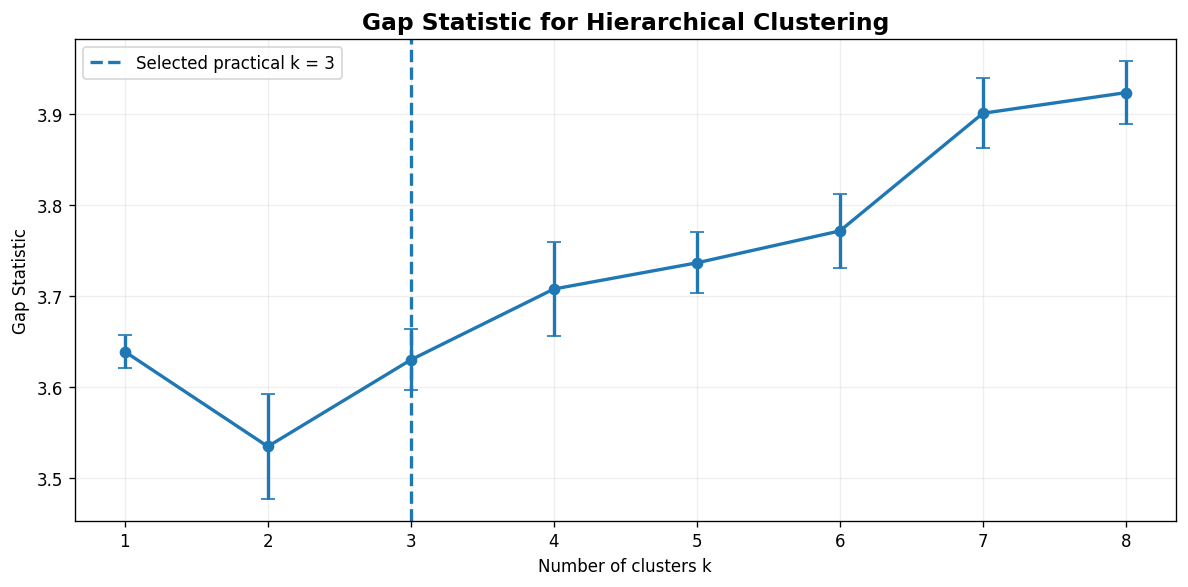

In [20]:
# ------------------------------------------------------------
# 6.5 Draw Gap Statistic chart with error bars
# ------------------------------------------------------------
# Goal:
# Visualise the Gap values and mark the selected practical hierarchical k.

# Start a clean figure.
plt.figure(figsize=(10, 5))

# Plot Gap value for each k with error bars.
plt.errorbar(
    gap_results["k"],
    gap_results["Gap"],
    yerr=gap_results["Gap_Error"],
    marker="o",
    linewidth=2,
    capsize=4
)

# Mark the selected practical hierarchical k.
plt.axvline(
    selected_gap_k,
    linestyle="--",
    linewidth=2,
    label=f"Selected practical k = {selected_gap_k}"
)

# Add chart labels and formatting.
plt.title("Gap Statistic for Hierarchical Clustering", fontsize=14, weight="bold")
plt.xlabel("Number of clusters k")
plt.ylabel("Gap Statistic")
plt.xticks(gap_results["k"])
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">What the Gap Statistic chart means</h3>

  <p>
    This chart shows the Gap Statistic for hierarchical clustering from <strong>k = 1</strong> to <strong>k = 8</strong>.
  </p>

  <p>
    The Gap value generally increases as the number of clusters increases.
    The highest tested value appears around <strong>k = 8</strong>.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Chart element</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Meaning</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Blue line</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Gap score for each tested k value.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Error bars</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Uncertainty from the bootstrap reference samples.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Dashed vertical line</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">The selected practical value: <strong>k = 3</strong>.</td>
      </tr>
    </tbody>
  </table>

  <p>
    The mathematical Gap result does not give a clean stopping point here.
    It keeps improving as k increases, which means more clusters continue to reduce spread.
  </p>

  <div style="
    border-left: 4px solid #f59e0b;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Important:</strong><br>
    The highest Gap value does not automatically become the final business choice.
    More clusters can improve mathematical separation, but they can also make the customer segmentation harder to explain.
  </div>

  <p>
    We selected <strong>k = 3</strong> because the dendrogram showed a strong merge-distance jump before the model started forcing very different groups together.
  </p>

  <div style="
    border-left: 4px solid #22c55e;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Conclusion:</strong><br>
    Gap Statistic is used as supporting evidence.
    The final practical hierarchical clustering choice remains <strong>k = 3</strong>,
    because it is supported by the dendrogram and gives a cleaner business story.
  </div>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">7. Practical hierarchical clustering result</h3>

  <p>
    Now we run Ward hierarchical clustering using the selected k from the Gap Statistic.
  </p>

  <p>
    This gives every customer a hierarchical cluster label.
  </p>

  <div style="
    border-left: 4px solid #38bdf8;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Simple idea:</strong><br>
    Gap Statistic helps choose k. Ward clustering creates the final hierarchical customer groups.
  </div>

</div>


In [22]:
# ------------------------------------------------------------
# 7.1 Run final hierarchical clustering
# ------------------------------------------------------------
# Goal:
# Create the final Ward hierarchical cluster labels using the selected practical k.

# Use the practical k chosen from the dendrogram + Gap Statistic section.
hierarchical_k = selected_gap_k

# Run Ward hierarchical clustering on the full scaled RFM table.
hierarchical_labels = run_ward_clustering(
    X_scaled,
    n_clusters=hierarchical_k
)

# Save one hierarchical label per customer.
hierarchical_result = pd.DataFrame({
    "CustomerID": rfm["CustomerID"],
    "Hierarchical_Cluster": hierarchical_labels
})

# Create a business profile using original RFM values.
hierarchical_profile = create_cluster_profile(
    hierarchical_labels,
    "Hierarchical_Cluster"
)

# Calculate clustering scores for the hierarchical result.
hierarchical_metrics = calculate_clustering_scores(
    X_scaled,
    hierarchical_labels,
    ignore_noise=False
)

# Save customer-level hierarchical labels.
hierarchical_result.to_csv(
    OUTPUT_DIR / "hierarchical_cluster_labels.csv",
    index=False
)

# Save hierarchical business profile.
hierarchical_profile.to_csv(
    OUTPUT_DIR / "hierarchical_cluster_profile.csv",
    index=False
)

print("Hierarchical clusters:", len(np.unique(hierarchical_labels)))
print("Hierarchical Silhouette:", round(hierarchical_metrics["Silhouette"], 4))

display(hierarchical_profile)

Hierarchical clusters: 3
Hierarchical Silhouette: 0.5752


,Hierarchical_Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Customer_Share_%,Revenue_Share_%
0,0,3420,48.37,4.81,2018.68,6903893.28,79.31,78.47
1,1,13,4.23,111.54,112047.39,1456616.06,0.30,16.56
2,2,879,258.99,1.49,497.98,437724.39,20.38,4.98


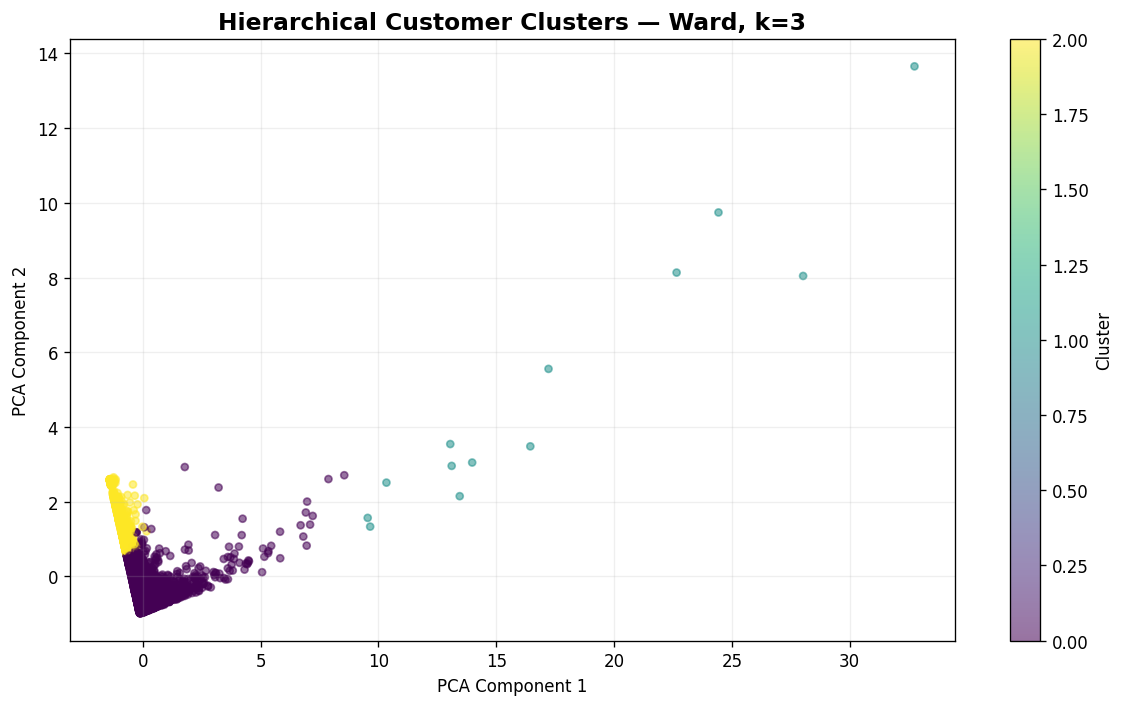

In [23]:
# ------------------------------------------------------------
# 7.2 Draw hierarchical clusters on PCA map
# ------------------------------------------------------------
# Goal:
# Show the final hierarchical clusters on the same PCA customer map.

plot_cluster_map(
    pca_view,
    hierarchical_labels,
    f"Hierarchical Customer Clusters — Ward, k={hierarchical_k}"
)

In [24]:
# ------------------------------------------------------------
# 7.3 Explain hierarchical result using actual values
# ------------------------------------------------------------

largest_cluster = hierarchical_profile.sort_values("Customers", ascending=False).iloc[0]
highest_revenue_cluster = hierarchical_profile.sort_values("Revenue_Share_%", ascending=False).iloc[0]

html = f"""
<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">What the hierarchical result means</h3>

  <p>
    Ward hierarchical clustering created <strong>{hierarchical_k}</strong> customer groups.
  </p>

  <p>
    The Silhouette score is <strong>{hierarchical_metrics['Silhouette']:.4f}</strong>.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Observation</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Actual result</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Largest cluster</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Cluster {int(largest_cluster['Hierarchical_Cluster'])} with {int(largest_cluster['Customers']):,} customers.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Highest revenue-share cluster</td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Cluster {int(highest_revenue_cluster['Hierarchical_Cluster'])} with {highest_revenue_cluster['Revenue_Share_%']:.2f}% revenue share.</td>
      </tr>
    </tbody>
  </table>

  <div style="
    border-left: 4px solid #38bdf8;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Business takeaway:</strong><br>
    Hierarchical clustering gives a tree-based segmentation view.
    It is useful for understanding customer similarity structure and comparing against K-Means.
  </div>

</div>
"""

display(HTML(html))


Observation,Actual result
Largest cluster,"Cluster 0 with 3,420 customers."
Highest revenue-share cluster,Cluster 0 with 78.47% revenue share.


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">8. Compare Hierarchical, K-Means and DBSCAN</h3>

  <p>
    Now we compare the hierarchical result with the two important earlier methods.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Method</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Question it answers</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>K-Means</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Can we create clean, stable customer segments?</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>DBSCAN</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Which customers are dense, and which are unusual?</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Hierarchical</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">How do customer groups merge into a tree structure?</td>
      </tr>
    </tbody>
  </table>

  <div style="
    border-left: 4px solid #22c55e;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Goal of this step:</strong><br>
    Compare the methods using Silhouette, Davies-Bouldin and Calinski-Harabasz.
  </div>

</div>


In [25]:
# ------------------------------------------------------------
# 8.1 Create final clustering comparison table
# ------------------------------------------------------------
# Goal:
# Compare Hierarchical clustering with the earlier K-Means and DBSCAN results.

# Get the K-Means baseline result from Notebook 2.
kmeans_row = partitioning_comparison[
    partitioning_comparison["Method"] == "K-Means"
].iloc[0]

# Get practical DBSCAN labels from Notebook 3.
dbscan_labels = dbscan_result["DBSCAN_Cluster"].values

# Calculate DBSCAN scores while ignoring DBSCAN noise customers.
dbscan_metrics = calculate_clustering_scores(
    X_scaled,
    dbscan_labels,
    ignore_noise=True
)

# Create a side-by-side comparison table.
final_clustering_comparison = pd.DataFrame([
    {
        "Method": "K-Means k=5",
        "Role": "Main segmentation baseline",
        "Clusters": int(kmeans_row["Clusters"]),
        "Noise_Customers": 0,
        "Silhouette": float(kmeans_row["Silhouette"]),
        "Davies_Bouldin": float(kmeans_row["Davies_Bouldin"]),
        "Calinski_Harabasz": float(kmeans_row["Calinski_Harabasz"])
    },
    {
        "Method": "DBSCAN",
        "Role": "Density and noise detection",
        "Clusters": len(set(dbscan_labels) - {-1}),
        "Noise_Customers": int((dbscan_labels == -1).sum()),
        "Silhouette": dbscan_metrics["Silhouette"],
        "Davies_Bouldin": dbscan_metrics["Davies_Bouldin"],
        "Calinski_Harabasz": dbscan_metrics["Calinski_Harabasz"]
    },
    {
        "Method": f"Hierarchical Ward k={hierarchical_k}",
        "Role": "Tree-based segmentation",
        "Clusters": hierarchical_k,
        "Noise_Customers": 0,
        "Silhouette": hierarchical_metrics["Silhouette"],
        "Davies_Bouldin": hierarchical_metrics["Davies_Bouldin"],
        "Calinski_Harabasz": hierarchical_metrics["Calinski_Harabasz"]
    }
]).round(4)

# Save comparison table for reporting and Notebook 5.
final_clustering_comparison.to_csv(
    OUTPUT_DIR / "hierarchical_kmeans_dbscan_comparison.csv",
    index=False
)

final_clustering_comparison

,Method,Role,Clusters,Noise_Customers,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means k=5,Main segmentation baseline,5,0,0.6140,0.6304,4006.5535
1,DBSCAN,Density and noise detection,3,63,0.6259,0.3119,68.1318
2,Hierarchical Ward k=3,Tree-based segmentation,3,0,0.5752,0.5914,3149.7195


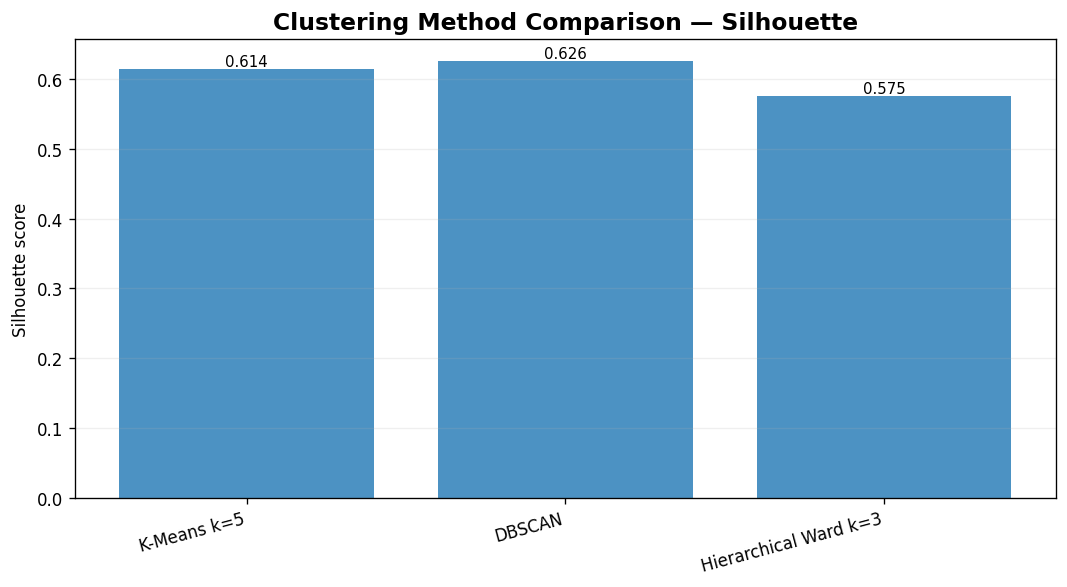

In [26]:
# ------------------------------------------------------------
# 8.2 Draw Silhouette comparison chart
# ------------------------------------------------------------
# Higher Silhouette is better.

chart_data = final_clustering_comparison.copy()

plt.figure(figsize=(9, 5))

bars = plt.bar(
    chart_data["Method"],
    chart_data["Silhouette"],
    alpha=0.80
)

plt.title("Clustering Method Comparison — Silhouette", fontsize=14, weight="bold")
plt.ylabel("Silhouette score")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.2)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


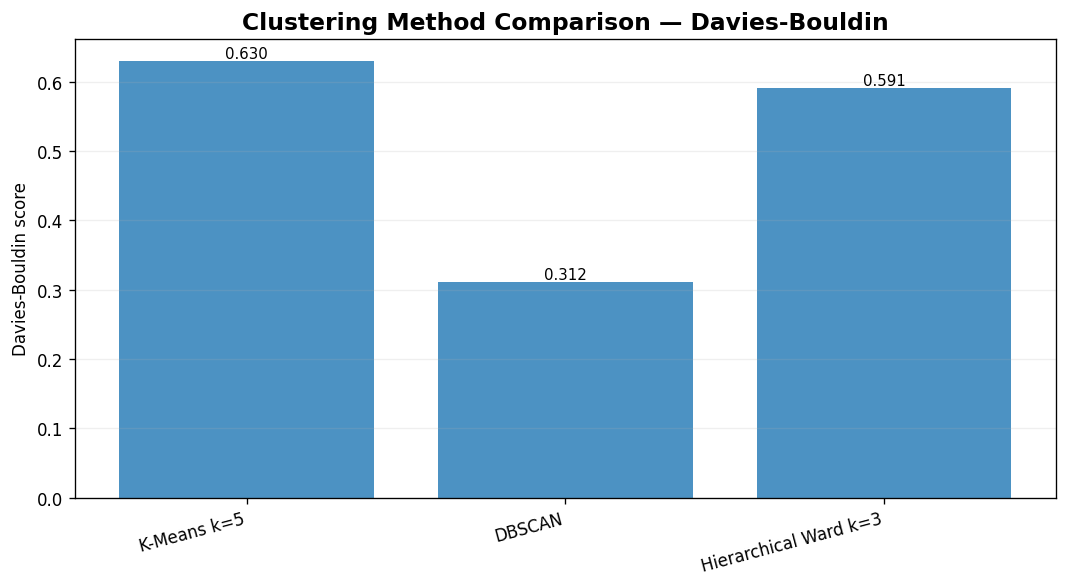

In [27]:
# ------------------------------------------------------------
# 8.3 Draw Davies-Bouldin comparison chart
# ------------------------------------------------------------
# Lower Davies-Bouldin is better.

plt.figure(figsize=(9, 5))

bars = plt.bar(
    chart_data["Method"],
    chart_data["Davies_Bouldin"],
    alpha=0.80
)

plt.title("Clustering Method Comparison — Davies-Bouldin", fontsize=14, weight="bold")
plt.ylabel("Davies-Bouldin score")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.2)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


In [28]:
# ------------------------------------------------------------
# 8.4 Explain final comparison using actual values
# ------------------------------------------------------------

best_silhouette_row = final_clustering_comparison.sort_values("Silhouette", ascending=False).iloc[0]
best_davies_row = final_clustering_comparison.sort_values("Davies_Bouldin", ascending=True).iloc[0]

html = f"""
<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">What the final comparison means</h3>

  <p>
    The best Silhouette score in this run belongs to <strong>{best_silhouette_row['Method']}</strong>
    with a score of <strong>{best_silhouette_row['Silhouette']:.4f}</strong>.
  </p>

  <p>
    The best Davies-Bouldin score in this run belongs to <strong>{best_davies_row['Method']}</strong>
    with a score of <strong>{best_davies_row['Davies_Bouldin']:.4f}</strong>.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Method</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Best use</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>K-Means</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Main clean segmentation baseline.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>DBSCAN</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Unusual customer and noise detection.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Hierarchical</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Tree-based explanation of customer similarity.</td>
      </tr>
    </tbody>
  </table>

  <div style="
    border-left: 4px solid #38bdf8;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Important:</strong><br>
    The highest metric does not automatically mean the best business method.
    We choose the final recommendation based on clarity, stability, and business usefulness.
  </div>

</div>
"""

display(HTML(html))


Method,Best use
K-Means,Main clean segmentation baseline.
DBSCAN,Unusual customer and noise detection.
Hierarchical,Tree-based explanation of customer similarity.


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">9. Final recommendation</h3>

  <p>
    This notebook completes the hierarchical clustering and Gap Statistic part of Learning Day 8.
  </p>

  <p>
    Hierarchical clustering gives us a tree-based view of customer similarity.
    The dendrogram helps us understand where customer groups naturally merge.
    The Gap Statistic adds a systematic check across <strong>k = 1 to 8</strong>.
  </p>

  <table style="border-collapse: collapse; width: 100%; margin: 12px 0;">
    <thead>
      <tr>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Method</th>
        <th style="text-align: left; padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Final role</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>K-Means</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Main customer segmentation baseline.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>DBSCAN</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Unusual customer and density-based noise detection.</td>
      </tr>
      <tr>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);"><strong>Hierarchical</strong></td>
        <td style="padding: 8px; border-bottom: 1px solid var(--vscode-panel-border);">Tree-based explanation and validation layer.</td>
      </tr>
    </tbody>
  </table>

  <div style="
    border-left: 4px solid #22c55e;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Final direction:</strong><br>
    Keep <strong>K-Means k = 5</strong> as the main business segmentation baseline.
    Use <strong>DBSCAN</strong> for unusual-customer detection.
    Use <strong>Hierarchical clustering</strong> to explain customer similarity through a tree-based view.
  </div>

</div>

In [29]:
# ------------------------------------------------------------
# 9.1 Show saved output files
# ------------------------------------------------------------

saved_outputs = pd.DataFrame({
    "Output_File": [
        "hierarchical_gap_statistic_results.csv",
        "hierarchical_cluster_labels.csv",
        "hierarchical_cluster_profile.csv",
        "hierarchical_kmeans_dbscan_comparison.csv"
    ],
    "Purpose": [
        "Gap Statistic results for k = 1 to 8",
        "Customer-level hierarchical cluster labels",
        "Business profile of hierarchical clusters",
        "Final comparison of Hierarchical, K-Means and DBSCAN"
    ]
})

saved_outputs


,Output_File,Purpose
0,hierarchical_gap_statistic_results.csv,Gap Statistic results for k = 1 to 8
1,hierarchical_cluster_labels.csv,Customer-level hierarchical cluster labels
2,hierarchical_cluster_profile.csv,Business profile of hierarchical clusters
3,hierarchical_kmeans_dbscan_comparison.csv,"Final comparison of Hierarchical, K-Means and ..."


In [30]:
# ------------------------------------------------------------
# 9.2 Explain saved outputs
# ------------------------------------------------------------
# Goal:
# Add a final output conclusion for the saved files.

html = f"""
<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">What was saved from this notebook</h3>

  <p>
    This notebook saved <strong>{len(saved_outputs)}</strong> output files into the <code>outputs/</code> folder.
  </p>

  <p>
    These files keep the Gap Statistic results, final hierarchical labels, cluster profiles, and comparison table.
  </p>

  <div style="
    border-left: 4px solid #22c55e;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Simple takeaway:</strong><br>
    Notebook 4 is ready for the final MVD proof notebook.
    The next notebook can use these saved outputs to show that hierarchical clustering and Gap Statistic were completed properly.
  </div>

</div>
"""

display(HTML(html))

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

  <h3 style="margin-bottom: 6px;">What comes next</h3>

  <p>
    The next notebook is the final MVD checklist and assignment-proof notebook.
  </p>

  <p>
    It will not introduce a new clustering method.
    It will prove that the required tasks were completed across the project notebooks.
  </p>

  <div style="
    border-left: 4px solid #38bdf8;
    padding: 10px 14px;
    margin: 12px 0;
    background: var(--vscode-editorWidget-background);
    border-radius: 6px;
  ">
    <strong>Notebook 5:</strong><br>
    MVD checklist, coverage proof, final project summary, and submission-ready explanation.
  </div>

</div>
